# Problem Statement
To predict which passengers were transported to another dimension (unsafe) and who remained in the spaceship (safe) after a spacetime anomaly.

### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [2]:
data_frame = pd.read_csv('./data/spaceship_titanic.csv')
data_frame.sample(3)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
2661,2853_01,Earth,False,F/544/S,TRAPPIST-1e,20.0,False,56.0,757.0,111.0,0.0,0.0,Lonnez Browlerson,True
1289,1370_01,Earth,False,E/102/S,TRAPPIST-1e,21.0,False,965.0,0.0,23.0,3.0,0.0,Timmy Waterson,False
4351,4632_04,Europa,False,C/176/S,TRAPPIST-1e,52.0,False,2.0,364.0,0.0,2144.0,1804.0,Alraium Syncepul,False


In [3]:
data_frame.shape

(8693, 14)

In [4]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [5]:
data_frame.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [6]:
spending_subset = data_frame.loc[:, 'RoomService' : 'VRDeck'].columns
data_frame.groupby('VIP')[spending_subset].mean()

,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
VIP,,,,,
False,217.218527,426.336536,173.876298,301.711045,282.718056
True,473.615385,1811.393782,247.726804,760.710660,1234.856410


#### VIP spends more than regular people

In [7]:
data_frame.groupby(['CryoSleep','VIP'])[spending_subset].mean()

RoomService    FoodCourt  ShoppingMall         Spa  \
CryoSleep VIP                                                         
False     False   342.476380   668.742608    272.831352  475.816971   
          True    491.473684  2017.725146    282.700000  837.971264   
True      False     0.000000     0.000000      0.000000    0.000000   
          True      0.000000     0.000000      0.000000    0.000000   

                      VRDeck  
CryoSleep VIP                 
False     False   446.904715  
          True   1329.627907  
True      False     0.000000  
          True      0.000000

#### Prople in deepsleep is not spending any money on spaceship servies.
Therefore wherever CryoSleep is True their spending should be 0 and vice-versa.

In [8]:
temporary_subset = data_frame['CryoSleep'] == True
data_frame.loc[temporary_subset, spending_subset] = 0.0
data_frame.sample(5)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
5382,5750_01,Earth,False,E/363/P,TRAPPIST-1e,18.0,False,0.0,625.0,0.0,0.0,356.0,Herina Parklaney,False
289,0320_01,Earth,False,G/44/S,TRAPPIST-1e,18.0,False,0.0,2.0,0.0,NaN,0.0,Breney Bellarkerd,False
4277,4557_01,Earth,False,E/286/P,TRAPPIST-1e,17.0,False,0.0,656.0,295.0,0.0,35.0,Dwin Mirez,False
3694,3967_01,Mars,False,F/819/P,TRAPPIST-1e,22.0,False,886.0,55.0,0.0,0.0,NaN,Ray Seen,False
2670,2861_01,Earth,False,F/547/S,TRAPPIST-1e,17.0,False,5.0,756.0,0.0,0.0,0.0,Evaley Marson,True


In [9]:
data_frame.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     113
FoodCourt       113
ShoppingMall    112
Spa             118
VRDeck          126
Name            200
Transported       0
dtype: int64

In [10]:
for spends in spending_subset:
    for value in [True, False]:
        temporary_subset = data_frame['VIP'] == value
        k = data_frame.loc[temporary_subset, spends].astype(float).mean()
        data_frame.loc[temporary_subset, spends] = data_frame.loc[temporary_subset, spends].fillna(k)

In [11]:
data_frame.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService       2
FoodCourt         2
ShoppingMall      3
Spa               1
VRDeck            1
Name            200
Transported       0
dtype: int64

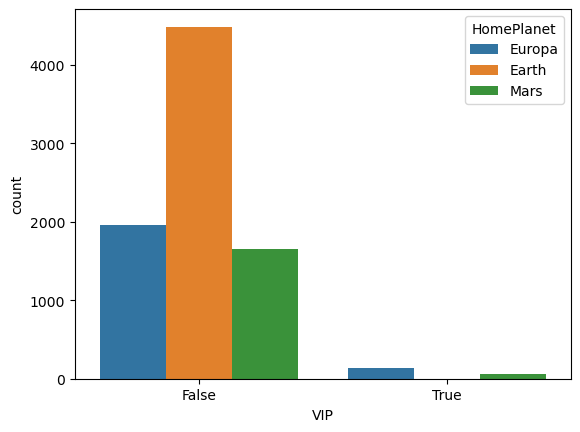

In [12]:
sb.countplot(data=data_frame, x='VIP', hue='HomePlanet')
plt.show()

In [13]:
col = 'HomePlanet'
temp = data_frame['VIP'] == False
data_frame.loc[temp, col] = data_frame.loc[temp, col].fillna('Earth')

temp = data_frame['VIP'] == True
data_frame.loc[temp, col] = data_frame.loc[temp, col].fillna('Europa')



In [14]:
data_frame.isnull().sum()

PassengerId       0
HomePlanet        3
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService       2
FoodCourt         2
ShoppingMall      3
Spa               1
VRDeck            1
Name            200
Transported       0
dtype: int64

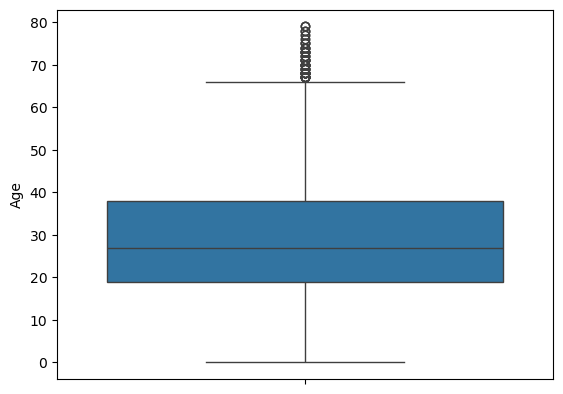

In [15]:
sb.boxplot(data_frame['Age'])
plt.show()

In [16]:
temp = data_frame[data_frame['Age'] < 60]['Age'].mean()
data_frame['Age'] = data_frame['Age'].fillna(temp)

In [17]:
data_frame.isnull().sum()

PassengerId       0
HomePlanet        3
CryoSleep       217
Cabin           199
Destination     182
Age               0
VIP             203
RoomService       2
FoodCourt         2
ShoppingMall      3
Spa               1
VRDeck            1
Name            200
Transported       0
dtype: int64

In [18]:
mask = (data_frame[spending_subset] > 0).any(axis=1)
data_frame.loc[mask, 'CryoSleep'] = False

In [19]:
data_frame.isnull().sum()

PassengerId       0
HomePlanet        3
CryoSleep        88
Cabin           199
Destination     182
Age               0
VIP             203
RoomService       2
FoodCourt         2
ShoppingMall      3
Spa               1
VRDeck            1
Name            200
Transported       0
dtype: int64

In [20]:
for col in data_frame.columns:
    if (data_frame[col].isnull().sum() == 0):
        continue

    if (data_frame[col].dtype == object or data_frame[col].dtype == bool):
        data_frame[col] = data_frame[col].fillna(data_frame[col].mode()[0])
    else:
        data_frame[col] = data_frame[col].fillna(data_frame[col].mean())

C:\Users\arjit\AppData\Local\Temp\ipykernel_11928\4011992577.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_frame[col] = data_frame[col].fillna(data_frame[col].mode()[0])


In [21]:
data_frame.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
dtype: int64

In [22]:
newcol = data_frame["PassengerId"].str.split("_", n=1, expand=True)
data_frame["RoomNo"] = newcol[0].astype(int)
data_frame["PassengerNo"] = newcol[1].astype(int)

data_frame.drop(['PassengerId', 'Name'],
        axis=1, inplace=True)

In [23]:
data_frame.head(3)

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,RoomNo,PassengerNo
0,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,1,1
1,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,2,1
2,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,3,1


In [24]:
data_frame['LeasureBill'] = data_frame['RoomService'] + data_frame['FoodCourt'] + data_frame['ShoppingMall'] + data_frame['Spa'] + data_frame['VRDeck']

In [25]:
data_frame.head(5)

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,RoomNo,PassengerNo,LeasureBill
0,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,1,1,0.0
1,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,2,1,736.0
2,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,3,1,10383.0
3,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,3,2,5176.0
4,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,4,1,1091.0


### Exploratory Data Analysis

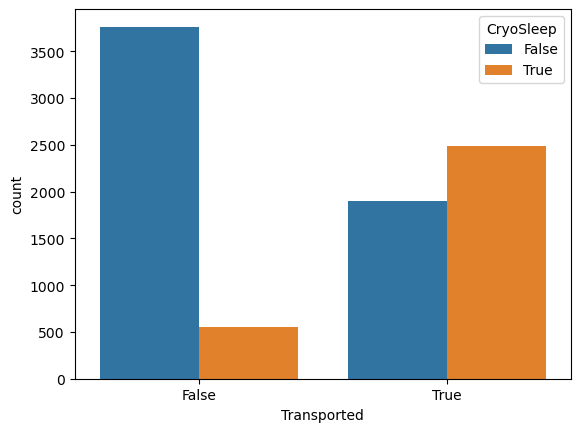

In [26]:
sb.countplot(data=data_frame,
             x='Transported',
             hue='CryoSleep')
plt.show()

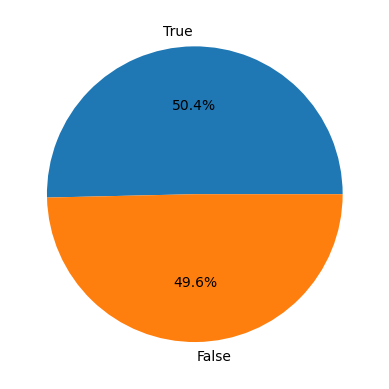

In [27]:
x = data_frame['Transported'].value_counts()
plt.pie(x.values,
        labels=x.index,
        autopct='%1.1f%%')
plt.show()

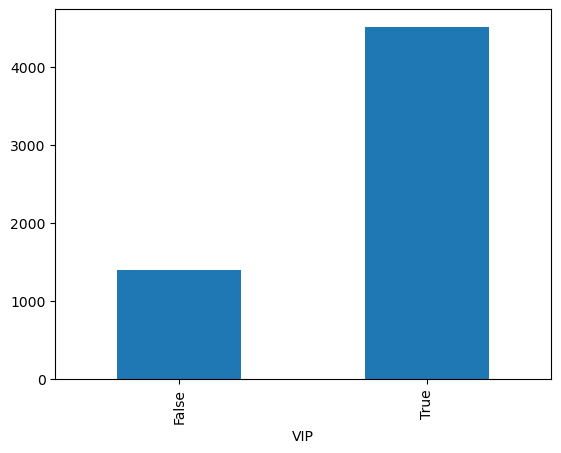

In [28]:
data_frame.groupby('VIP').mean(numeric_only=True)['LeasureBill'].plot.bar()
plt.show()

In [29]:
for col in data_frame.columns:
      # In case of categorical column 
    # encode them
    if data_frame[col].dtype == object:
        le = LabelEncoder()
        data_frame[col] = le.fit_transform(data_frame[col])

    # In case of boolean data type 
    # convert them to binary    
    if data_frame[col].dtype == 'bool':
        data_frame[col] = data_frame[col].astype(int)

data_frame.head()

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,RoomNo,PassengerNo,LeasureBill
0,1,0,149,2,39.0,0,0.0,0.0,0.0,0.0,0.0,0,1,1,0.0
1,0,0,2184,2,24.0,0,109.0,9.0,25.0,549.0,44.0,1,2,1,736.0
2,1,0,1,2,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0,3,1,10383.0
3,1,0,1,2,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0,3,2,5176.0
4,0,0,2186,2,16.0,0,303.0,70.0,151.0,565.0,2.0,1,4,1,1091.0


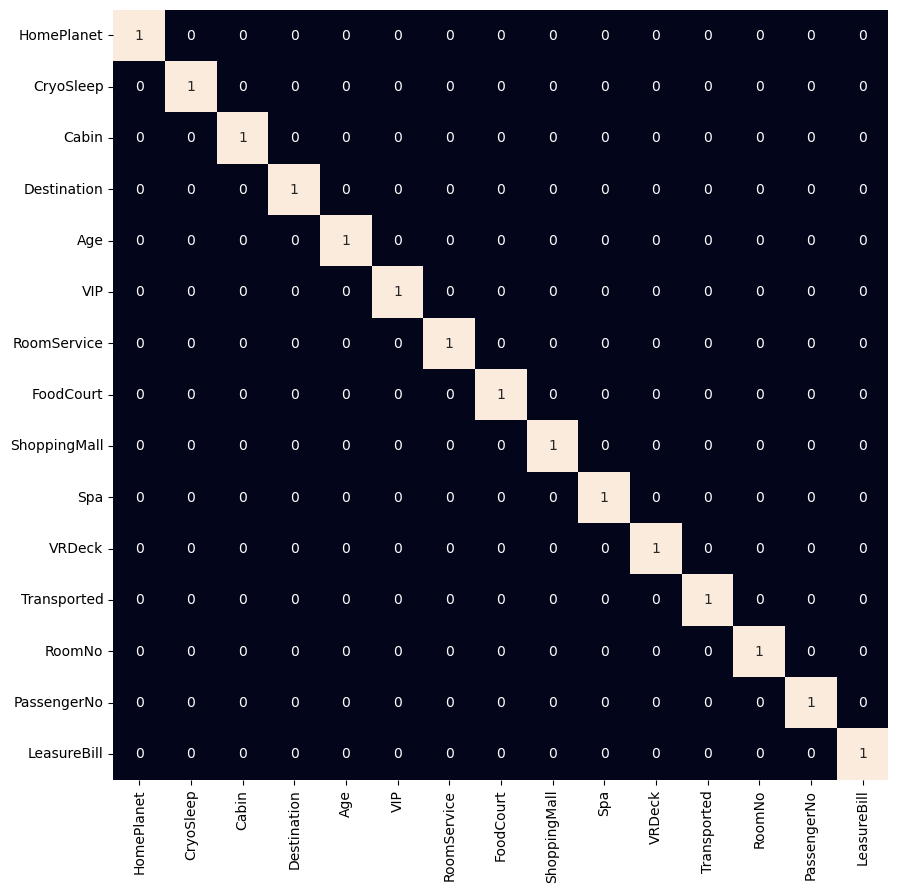

In [30]:
plt.figure(figsize=(10,10))
sb.heatmap(data_frame.corr()>0.8,
           annot=True,
           cbar=False)
plt.show()

### Model Training

In [31]:
features = data_frame.drop(['Transported'], axis=1)
target = data_frame.Transported

In [32]:
X_train, X_test, Y_train, Y_test = train_test_split(features, target, test_size=0.2, random_state=22)

X_train.shape, X_test.shape

((6954, 14), (1739, 14))

In [33]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score as ras
models = [LogisticRegression(), SVC(kernel='rbf', probability=True)]

for i in range(len(models)):
    models[i].fit(X_train, Y_train)
    print(f"{models[i]}: ")

    train_prediction = models[i].predict_proba(X_train)[:, 1]
    print('Training Accuracy : ', ras(Y_train, train_prediction))

    test_prediction = models[i].predict_proba(X_test)[:, 1]
    print('Testing Accuracy : ', ras(Y_test, test_prediction))
    print()

LogisticRegression(): 
Training Accuracy :  0.8700253831146243
Testing Accuracy :  0.8517032663243468

SVC(probability=True): 
Training Accuracy :  0.8877554287066192
Testing Accuracy :  0.8569703366851054



### Model Evaluation

#### Logistic Regression

[[645 221]
 [186 687]]


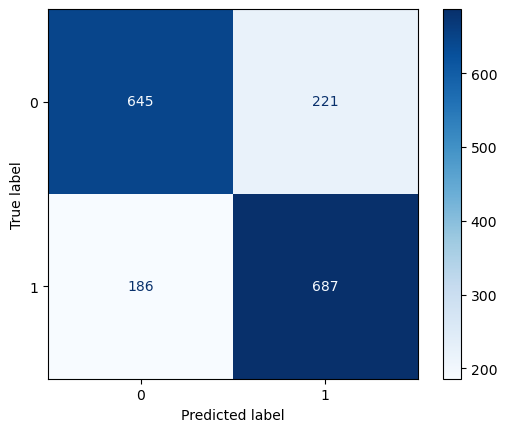

In [35]:
y_prediction = models[0].predict(X_test)
cm = confusion_matrix(Y_test, y_prediction)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=models[1].classes_)
disp.plot(cmap='Blues')
plt.show()

In [36]:
print(metrics.classification_report(Y_test, models[0].predict(X_test)))

              precision    recall  f1-score   support

           0       0.78      0.74      0.76       866
           1       0.76      0.79      0.77       873

    accuracy                           0.77      1739
   macro avg       0.77      0.77      0.77      1739
weighted avg       0.77      0.77      0.77      1739



#### Support Vector Classifier

[[663 203]
 [185 688]]


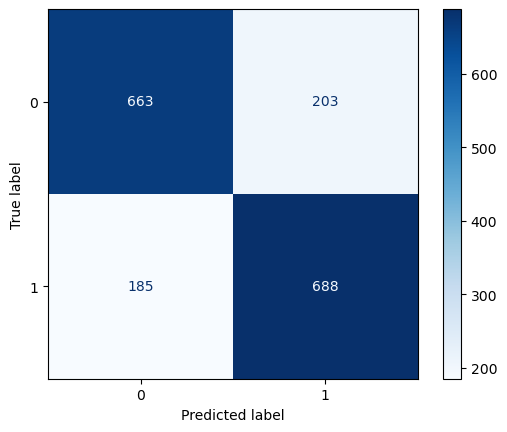

In [37]:
# Make predictions from testing data

y_prediction = models[1].predict(X_test)
cm = confusion_matrix(Y_test, y_prediction)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=models[1].classes_)
disp.plot(cmap='Blues')
plt.show()

In [38]:
print(metrics.classification_report(Y_test, models[1].predict(X_test)))

              precision    recall  f1-score   support

           0       0.78      0.77      0.77       866
           1       0.77      0.79      0.78       873

    accuracy                           0.78      1739
   macro avg       0.78      0.78      0.78      1739
weighted avg       0.78      0.78      0.78      1739

